Part 0: Repository Setup

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cuda


Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Part 1.1 — A single neuron is just a line

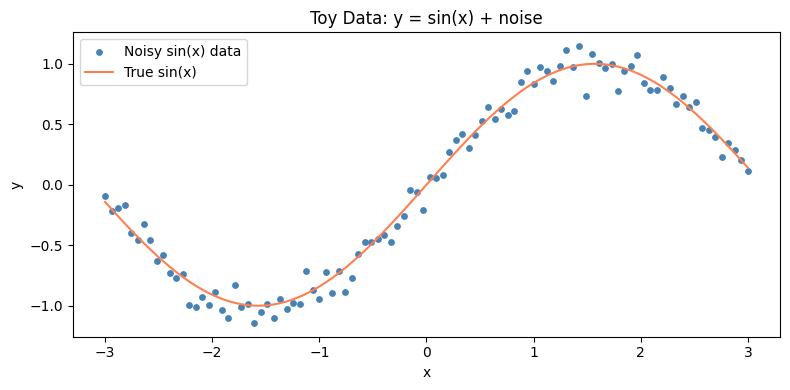

Final w = 0.3390,  b = -0.0104
Final loss = 0.1955


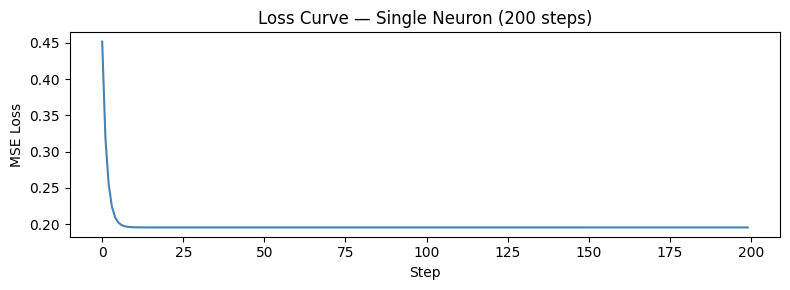

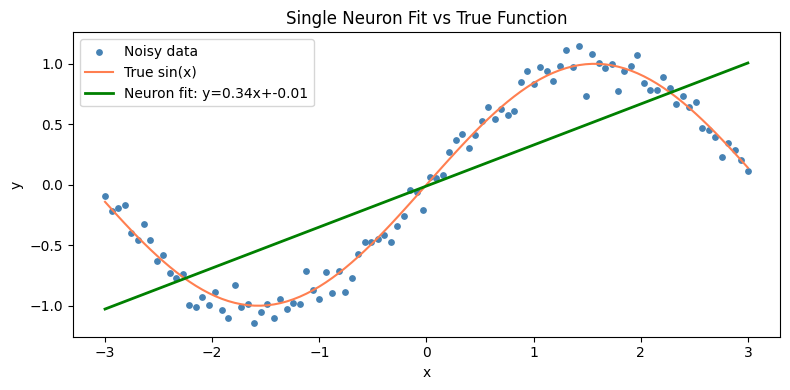

In [2]:
# Generate toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

# The plot of the raw data
plt.figure(figsize=(8, 4))
plt.scatter(x, y, s=15, color='steelblue', label='Noisy sin(x) data')
plt.plot(x, np.sin(x), color='coral', linewidth=1.5, label='True sin(x)')
plt.title('Toy Data: y = sin(x) + noise')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

# Initialise w and b to small random values
np.random.seed(RANDOM_STATE)
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

lr     = 0.05
steps  = 200
losses = []

# Gradient descent loop
for step in range(steps):
    # Forward pass: single neuron prediction
    y_hat = w * x + b

    # Loss: Mean Squared Error
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Gradients (derived from MSE loss by chain rule)
    dw = np.mean(2 * (y_hat - y) * x)   # dLoss/dw
    db = np.mean(2 * (y_hat - y))        # dLoss/db

    # Parameter update
    w -= lr * dw
    b -= lr * db

print(f"Final w = {w:.4f},  b = {b:.4f}")
print(f"Final loss = {losses[-1]:.4f}")

# Plot (a): Loss curve
plt.figure(figsize=(8, 3))
plt.plot(losses, color='steelblue')
plt.title('Loss Curve — Single Neuron (200 steps)')
plt.xlabel('Step')
plt.ylabel('MSE Loss')
plt.tight_layout()
plt.show()

# Plot (b): Data with fitted line
y_final = w * x + b

plt.figure(figsize=(8, 4))
plt.scatter(x, y, s=15, color='steelblue', label='Noisy data')
plt.plot(x, np.sin(x), color='coral', linewidth=1.5, label='True sin(x)')
plt.plot(x, y_final, color='green', linewidth=2, label=f'Neuron fit: y={w:.2f}x+{b:.2f}')
plt.title('Single Neuron Fit vs True Function')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

**Student Reasoning — The single neuron**

**1. Deriving dLoss/dw:**

Loss = (1/n) * Σ(y_hat - y)²    where y_hat = w*x + b

dLoss/dw = (1/n) * Σ 2(y_hat - y) * x

It matches the code:
dw = np.mean(2 * (y_hat - y) * x)  

**2. Underfitting or overfitting?**

This is underfitting. The loss curve shows the loss dropping quickly
from 0.45 and becoming flattened at 0.20
no matter how many more steps are run. The fit plot confirms this: the
neuron learned y = 0.34x - 0.01, a straight line that cuts through the
middle of the data but completely misses the curve. A single neuron
can never fit a sine wave because it can only compute w*x + b, which
is always a straight line. Sin(x) curves up, peaks, and curves back
down, no straight line can represent that shape no matter of how
long we continued training it.